[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/Quantlets/Ch_01/TSA_ch1_transformations/TSA_ch1_transformations.ipynb)

# TSA_ch1_transformations

Transformations: the S&P 500 log price and its first difference; Romanian real GDP in logs, quarterly and annual log differences with their ACF; the Box-Cox transformation of Romanian nominal GDP with the lambda of Guerrero (1993); over-differencing white noise.

*Time Series Analysis (TSA), Chapter 1: Stochastic processes and stationarity. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_1'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/Quantlets/Ch_01/TSA_ch1_transformations


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # default size about 7 inches wide (as in MFM); a chart is shown 11-13 cm wide on a slide, so these font sizes
    # give 7-9 pt text there. Multi-panel charts should stay near 7-7.6 inches wide: at 10-11 inches the axis
    # text drops to about 5 pt on the slide.
    rc['figure.figsize'] = (7.0, 3.4)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Analysis

In [5]:
from statsmodels.tsa.stattools import acf, pacf

from statsmodels.stats.diagnostic import acorr_ljungbox

SEED = 2026

GDP_REAL = ('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO')

GDP_NOMINAL = ('namq_10_gdp', 'Q.CP_MEUR.NSA.B1GQ.RO')

HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')

START = '2000-01-01'

BAND_COL = st.IDAred

NAME = {'bet': 'BET', 'sp500': 'S&P 500'}

def ro_gdp(kind='real'):
    """Romanian quarterly GDP (Eurostat), million EUR, not seasonally adjusted: 'real' or 'nominal'."""
    ds, key = GDP_REAL if kind == 'real' else GDP_NOMINAL
    return read_eurostat(ds, key).rename(f'gdp_{kind}')


def ro_hicp():
    """Romanian HICP (Eurostat, monthly, 2015 = 100)."""
    return read_eurostat(*HICP).rename('hicp')


def sample_acf(x, nlags=20):
    """Sample ACF rho(1..nlags) with the divisor T (as in Brockwell and Davis)."""
    return acf(np.asarray(x, float), nlags=nlags, fft=True)[1:]


def sample_pacf(x, nlags=20):
    """Sample PACF phi_hh, h = 1..nlags (Durbin-Levinson on the sample ACF)."""
    return pacf(np.asarray(x, float), nlags=nlags, method='ywm')[1:]


def ljung_box(x, m=10):
    """Ljung-Box Q*(m) and Box-Pierce Q(m) with their chi-square(m) p-values."""
    t = acorr_ljungbox(np.asarray(x, float), lags=[m], boxpierce=True, return_df=True).iloc[0]
    return {'lb': float(t['lb_stat']), 'lb_p': float(t['lb_pvalue']), 'bp': float(t['bp_stat']), 'bp_p': float(t['bp_pvalue'])}


def acf_bars(ax, r, T, color=st.MainBlue, theory=None, label='sample ACF', band=True):
    """ACF as bars at lags 1..len(r), with the +-1.96/sqrt(T) bands and optional theoretical values."""
    lags = np.arange(1, len(r) + 1)
    ax.bar(lags, r, width=0.55, color=color, label=label)
    if theory is not None:
        ax.plot(lags, theory, 'o', ms=4, color=st.Orange, label='theoretical ACF')
    if band:
        b = 1.96 / np.sqrt(T)
        ax.axhline(b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax.axhline(-b, color=BAND_COL, ls='--', lw=0.9, label='_nolegend_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlim(0.3, len(r) + 0.7)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


def simulate_arma(phi=(), theta=(), n=500, sigma=1.0, burn=500, rng=None):
    """X_t = sum phi_i X_{t-i} + e_t + sum theta_j e_{t-j}, e_t i.i.d. N(0, sigma^2), after a burn-in."""
    rng = rng if rng is not None else np.random.default_rng(SEED)
    e = rng.normal(0, sigma, n + burn)
    x = np.zeros(n + burn)
    p, q = len(phi), len(theta)
    for t in range(n + burn):
        x[t] = e[t] + sum(phi[i] * x[t - 1 - i] for i in range(p) if t - 1 - i >= 0) \
            + sum(theta[j] * e[t - 1 - j] for j in range(q) if t - 1 - j >= 0)
    return x[burn:]


def theoretical_acf(phi=(), theta=(), nlags=20):
    """Theoretical ACF of an ARMA process (statsmodels ArmaProcess), lags 1..nlags."""
    from statsmodels.tsa.arima_process import ArmaProcess
    return ArmaProcess(np.r_[1, -np.asarray(phi, float)], np.r_[1, np.asarray(theta, float)]).acf(nlags + 1)[1:]


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def fig_sp500_diff(save_it=True):
    """S&P 500: log price (a random-walk-like series) and daily log returns (its first difference)."""
    p = np.log(load_close('sp500', start=START))
    r = 100 * p.diff().dropna()
    fig, ax = plt.subplots(2, 1, figsize=(9.6, 4.3), sharex=True)
    ax[0].plot(p.index, p, color=st.MainBlue)
    ax[0].set_title(r'S&P 500: $\ln P_t$')
    ax[1].plot(r.index, r, color=st.IDAred, lw=0.5)
    ax[1].set_title(r'S&P 500: $r_t = 100\,\Delta \ln P_t = 100\,(1 - L)\ln P_t$ (%)')
    plt.tight_layout()
    save('tsa_ch1_sp500_diff', save_it)
    return {'n': int(len(r)), 'acf1_p': float(sample_acf(p, 1)[0]), 'acf50_p': float(sample_acf(p, 50)[-1]),
            'acf1_r': float(sample_acf(r, 1)[0]), 'mean_r': float(r.mean()), 'sd_r': float(r.std())}


def fig_gdp_transform(nlags=16, save_it=True):
    """Romanian real GDP (not seasonally adjusted): log level, quarterly and annual log differences, and their ACF."""
    g = np.log(ro_gdp('real'))
    d1 = (100 * g.diff()).dropna()
    d4 = (100 * g.diff(4)).dropna()
    fig, ax = plt.subplots(2, 3, figsize=(7.4, 3.4))
    for j, (lab, x, c) in enumerate([(r'$\ln Y_t$', g, st.MainBlue), (r'$100\,\Delta \ln Y_t$ (q/q, %)', d1, st.Forest),
                                     (r'$100\,\Delta_4 \ln Y_t$ (y/y, %)', d4, st.IDAred)]):
        ax[0, j].plot(x.index, x, color=c, lw=1.0)
        ax[0, j].set_title(lab, fontsize=11)
        import matplotlib.dates as mdates
        ax[0, j].xaxis.set_major_locator(mdates.YearLocator(10))
        ax[0, j].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        acf_bars(ax[1, j], sample_acf(x, nlags), len(x), color=c, label='_nolegend_')
        ax[1, j].set_title('ACF')
        ax[1, j].set_xlabel('lag (quarters)')
        ax[1, j].set_ylim(-0.6, 1.0)
    st.fig_legend_bottom(fig, ncol=1, y=-0.01)
    plt.tight_layout()
    save('tsa_ch1_gdp_transform', save_it)
    r0, r1, r4 = sample_acf(g, nlags), sample_acf(d1, nlags), sample_acf(d4, nlags)
    covid = d4['2020-04-01'] if pd.Timestamp('2020-04-01') in d4.index else float('nan')
    return {'n': int(len(g)), 'first': g.index[0].strftime('%Y-%m-%d'), 'last': g.index[-1].strftime('%Y-%m-%d'),
            'acf1_level': float(r0[0]), 'acf8_level': float(r0[7]), 'acf1_d1': float(r1[0]), 'acf4_d1': float(r1[3]),
            'acf2_d1': float(r1[1]), 'acf1_d4': float(r4[0]), 'acf4_d4': float(r4[3]), 'mean_d4': float(d4.mean()),
            'sd_d4': float(d4.std()), 'covid_d4': float(covid), 'mean_d1': float(d1.mean()), 'sd_d1': float(d1.std()),
            'last_d4': float(d4.iloc[-1]), 'band': 1.96 / np.sqrt(len(d1))}


def boxcox(y, lam):
    """Box-Cox transform: (y^lam - 1)/lam, or ln y for lam = 0."""
    y = np.asarray(y, float)
    return np.log(y) if abs(lam) < 1e-8 else (y ** lam - 1) / lam


def guerrero_cv(y, lam, period=4):
    """Guerrero (1993): coefficient of variation of sd_i / mean_i^(1 - lam) over non-overlapping blocks of one year."""
    y = np.asarray(y, float)
    nb = len(y) // period
    blocks = y[len(y) - nb * period:].reshape(nb, period)
    ratio = blocks.std(axis=1, ddof=1) / blocks.mean(axis=1) ** (1 - lam)
    return ratio.std(ddof=1) / ratio.mean()


def guerrero_lambda(y, period=4, grid=np.linspace(-1, 2, 301)):
    cv = np.array([guerrero_cv(y, l, period) for l in grid])
    return float(grid[np.argmin(cv)]), grid, cv


def fig_boxcox(save_it=True):
    """Romanian nominal GDP (not seasonally adjusted): the level, the Box-Cox transform with Guerrero's lambda,
    and the Guerrero criterion as a function of lambda."""
    y = ro_gdp('nominal')
    lam, grid, cv = guerrero_lambda(y.values)
    z = pd.Series(boxcox(y.values, lam), index=y.index)
    fig, ax = plt.subplots(1, 3, figsize=(10.4, 3.0))
    ax[0].plot(y.index, y / 1000, color=st.MainBlue)
    ax[0].set_title('Nominal GDP (bn EUR): $Y_t$')
    ax[1].plot(z.index, z, color=st.Forest)
    ax[1].set_title(rf'Box-Cox, $\lambda = {lam:.2f}$')
    ax[2].plot(grid, cv, color=st.IDAred)
    ax[2].axvline(lam, color=st.DarkText, ls='--', lw=0.8)
    ax[2].set_title(r"Guerrero's criterion against $\lambda$")
    ax[2].set_xlabel(r'$\lambda$')
    plt.tight_layout()
    save('tsa_ch1_boxcox', save_it)
    # seasonal amplitude: range within each year, early and late, in levels and after the transform
    yy = y.groupby(y.index.year).agg(lambda s: (s.max() - s.min()) / s.mean() if len(s) == 4 else np.nan).dropna()
    return {'lambda': lam, 'cv_lam': float(cv.min()), 'cv_1': float(guerrero_cv(y.values, 1.0)),
            'cv_0': float(guerrero_cv(y.values, 0.0)), 'first': y.index[0].strftime('%Y-%m-%d'),
            'last': y.index[-1].strftime('%Y-%m-%d'), 'v0': float(y.iloc[0] / 1000), 'v1': float(y.iloc[-1] / 1000),
            'amp_rel_0': float(yy.iloc[:5].mean()), 'amp_rel_1': float(yy.iloc[-5:].mean())}


def fig_overdiff(n=500, nlags=10, save_it=True):
    """Over-differencing: white noise has no autocorrelation; its first difference is an MA(1) with rho(1) = -0.5."""
    rng = np.random.default_rng(SEED + 11)
    e = rng.normal(size=n + 1)
    d = np.diff(e)
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 2.9), sharey=True)
    acf_bars(ax[0], sample_acf(e, nlags), n, color=st.MainBlue, label='sample ACF')
    acf_bars(ax[1], sample_acf(d, nlags), n, color=st.IDAred, theory=np.r_[-0.5, np.zeros(nlags - 1)], label='_nolegend_')
    ax[0].set_title(r'White noise $\varepsilon_t$')
    ax[1].set_title(r'Over-differenced: $\Delta\varepsilon_t = \varepsilon_t - \varepsilon_{t-1}$')
    for a in ax:
        a.set_xlabel('lag h')
    ax[0].set_ylim(-0.65, 0.3)
    st.fig_legend_bottom(fig, ncol=3, y=-0.03)
    plt.tight_layout()
    save('tsa_ch1_overdiff', save_it)
    return {'r1_e': float(sample_acf(e, 1)[0]), 'r1_d': float(sample_acf(d, 1)[0]), 'var_e': float(e.var()),
            'var_d': float(d.var())}

## Run

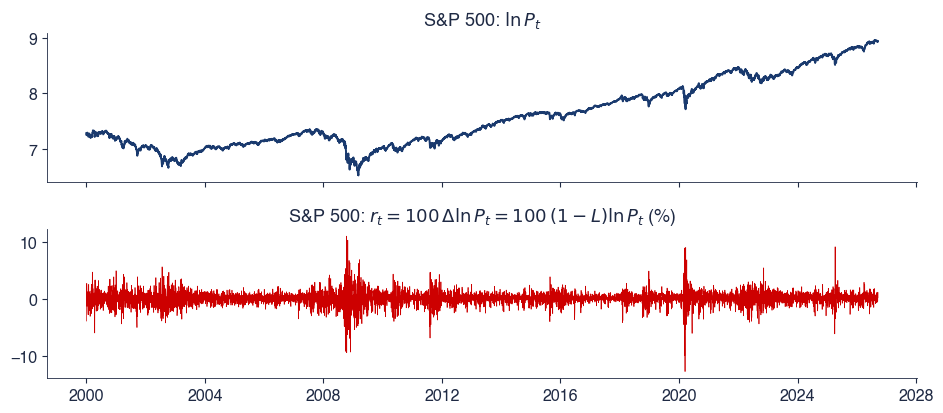

{'n': 6714, 'acf1_p': 0.9993929510283917, 'acf50_p': 0.9725695160982017, 'acf1_r': -0.09858040590252938, 'mean_r': 0.024718705886760773, 'sd_r': 1.213029590053411}


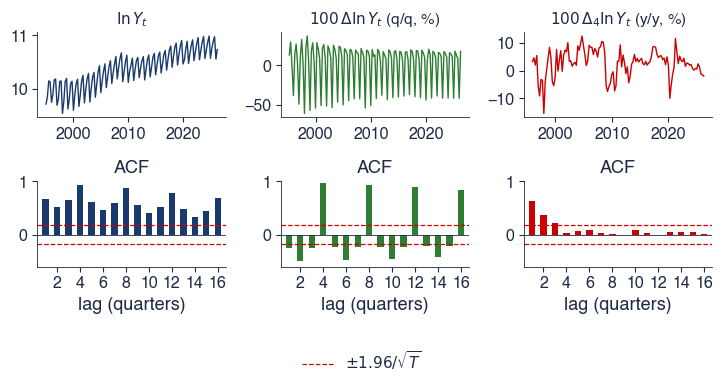

{'n': 126, 'first': '1995-01-01', 'last': '2026-04-01', 'acf1_level': 0.6776767077402106, 'acf8_level': 0.8672887112599226, 'acf1_d1': -0.24444787339616114, 'acf4_d1': 0.9626448699811928, 'acf2_d1': -0.4915901376351376, 'acf1_d4': 0.630753075092404, 'acf4_d4': 0.032799824841653086, 'mean_d4': 2.7266651505415864, 'sd_d4': 4.8467643132576015, 'covid_d4': -9.867861354703145, 'mean_d1': 0.8194029543606038, 'sd_d1': 27.482868048369014, 'last_d4': -1.9582590848228776, 'band': np.float64(0.1753077294359835)}


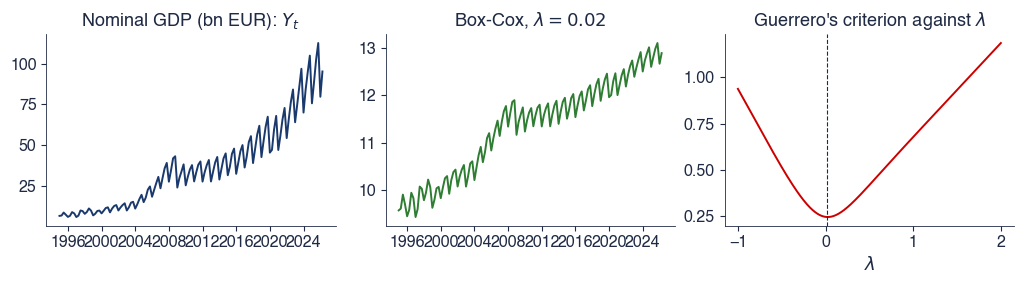

{'lambda': 0.020000000000000018, 'cv_lam': 0.24252265840615622, 'cv_1': 0.6770144858048807, 'cv_0': 0.24329054762456906, 'first': '1995-01-01', 'last': '2026-04-01', 'v0': 6.370100000000001, 'v1': 95.2342, 'amp_rel_0': 0.38574369531462604, 'amp_rel_1': 0.41033397911299}


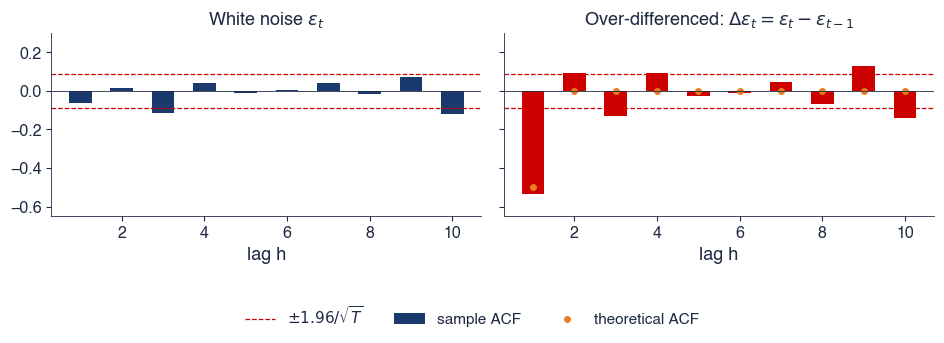

{'r1_e': -0.06156746820804763, 'r1_d': -0.5355782668102355, 'var_e': 0.947582603561119, 'var_d': 2.0114005834735917}


In [6]:
print(fig_sp500_diff())
print(fig_gdp_transform())
print(fig_boxcox())
print(fig_overdiff())

![tsa_ch1_sp500_diff](./tsa_ch1_sp500_diff.png)

Output: `tsa_ch1_sp500_diff.pdf`

![tsa_ch1_gdp_transform](./tsa_ch1_gdp_transform.png)

Output: `tsa_ch1_gdp_transform.pdf`

![tsa_ch1_boxcox](./tsa_ch1_boxcox.png)

Output: `tsa_ch1_boxcox.pdf`

![tsa_ch1_overdiff](./tsa_ch1_overdiff.png)

Output: `tsa_ch1_overdiff.pdf`